# 03 — Local SLM Battery Control · Google Colab

**Phase 2** · MSc Thesis
Supervisor: Dr. Panagiotis Kasnesis | Student: Antonios Bastoulis

---

Runs the language model **locally on the Colab GPU** instead of remote API calls. Fully self-contained: state rendering, action parsing, prompt definitions, and rollout logic defined inline. Only external dependency is `src/env.py`.

**Single-agent setup (Phase 3 design):**

One SLM controls `TRAINING_BUILDINGS=[0,1,2]`. One inference call per step, 3 actions per call. At Phase 4 deployment the same LoRA loads into two agents (α on B0–2, β on B3–5); for training/eval through Phase 3 we stay single-agent to halve inference cost.


## § 0 — Runtime & Config

All knobs in one place: the SLM model ID and 4-bit toggle, the experiment window (matches nb 02 — `t=3624..3923`), the single-agent 3-building slice, and the local Colab output dir. `TRAINING_BUILDINGS` is also bound here as a fallback so this cell runs cleanly **before** the repo is cloned in § 2 — § 3 re-imports the canonical version from `src.env` once the clone lands.

`MODEL_ID` can be swapped to any HuggingFace causal LM (`Qwen3-4B`, `Phi-3.5-mini`, `Llama-3-8B`, etc.). For 8B models on T4 keep `LOAD_IN_4BIT=True`.

In [1]:
import os, sys, subprocess, time, warnings, json, random
import numpy as np

# ── Runtime check ─────────────────────────────────────────────────────────
try:
    import torch
    if torch.cuda.is_available():
        _gpu  = torch.cuda.get_device_name(0)
        _vram = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"GPU: {_gpu}  ({_vram:.1f} GB VRAM)")
    else:
        print("No GPU — set Runtime → Change runtime type → T4 GPU")
except ImportError:
    print("torch not yet installed — will be in § 1")

# ── Model selection ────────────────────────────────────────────────────────
# Unsloth's Gemma-4 mirror: identical weights to google/gemma-4-E4B-it but
# NOT gated (no HF token / license click-through) and the same repo nb 05/06
# load — keeps the whole pipeline on one model source.
MODEL_ID:     str  = "unsloth/gemma-4-E4B-it"
# Qwen/Qwen3-4B-Instruct-2507 also a good choice
LOAD_IN_4BIT: bool = True
MAX_NEW_TOKENS: int = 400

HF_TOKEN: str  = os.environ.get("HF_TOKEN")
GITHUB_REPO: str = "https://github.com/antonisbast/eclipse-thesis"

# ── Experiment window (matches 02_llm_policy) ─────────────────────────────
WEEK_START: int = 3624
WEEK_LEN:   int = 504

# ── Single-agent buildings (Phase 3 design — see CLAUDE.md) ───────────────
# Import inside this cell after the repo is cloned (§ 2). At Phase 4 the same
# model deploys into two agents over BUILDINGS=[0..5] without retraining.
# The list is defined inline here as a fallback so this cell runs standalone
# in fresh Colab kernels; § 3 re-imports the canonical constants.
TRAINING_BUILDINGS: list = [0, 1, 2]
BUILDINGS_RUN:      list = TRAINING_BUILDINGS
N_BLDGS:            int  = len(BUILDINGS_RUN)

# ── Local output ──────────────────────────────────────────────────────────
LOCAL_OUTDIR: str = "/content/eclipse-thesis/notebooks/artifacts"
os.makedirs(LOCAL_OUTDIR, exist_ok=True)

print(f"\nModel          : {MODEL_ID}")
print(f"4-bit quant    : {LOAD_IN_4BIT}")
print(f"Max new tokens : {MAX_NEW_TOKENS}")
print(f"Window         : t{WEEK_START}..{WEEK_START + WEEK_LEN - 1} ({WEEK_LEN} steps)")
print(f"Single agent   : buildings {BUILDINGS_RUN}  (N_BLDGS={N_BLDGS})")


GPU: Tesla T4  (15.6 GB VRAM)

Model          : unsloth/gemma-4-E4B-it
4-bit quant    : True
Max new tokens : 400
Window         : t3624..4127 (504 steps)
Single agent   : buildings [0, 1, 2]  (N_BLDGS=3)


## § 1 — Install Dependencies

Two installs, in order. CityLearn first (`--no-deps` to avoid the legacy EnergyPlus extras pip resolver pulls in by default — we only need the runtime), pinned to **2.6.0b2** because `src.eval` uses `evaluate_v2()` which only exists in 2.6+. Then the ML stack: `transformers` **pinned to 5.5.0** — the version the official Unsloth Gemma-4 tutorial requires for Gemma 4, and the same pin nb 05/06 use — plus `tokenizers`, `accelerate`, `bitsandbytes` (4-bit quantisation), `sentencepiece`, and `timm` (Gemma 4 carries vision/audio towers that `transformers` loads even on the text path).

In [2]:
# CityLearn 2.6 is a pre-release on PyPI — pin the version explicitly so we
# get the same evaluate_v2() API as the rest of the pipeline (nb 04 / 05 / 06).
# --no-deps because CityLearn pulls heavy/legacy deps we don't need at eval
# time (e.g. some EnergyPlus extras). Runtime deps installed explicitly above.
CITYLEARN_VERSION = "2.6.0b2"

!pip install -q numpy gymnasium doe-xstock nrel-pysam
!pip install -q --pre "CityLearn=={CITYLEARN_VERSION}" --no-deps

import citylearn
assert citylearn.__version__.startswith("2.6"), (
    f"Expected CityLearn 2.6.x, got {citylearn.__version__}. "
    f"src.eval depends on evaluate_v2() which only exists in 2.6+."
)
print(f"✓ CityLearn {citylearn.__version__}")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.1/77.1 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.7/107.7 kB 4.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.6/423.6 kB 8.3 MB/s eta 0:00:00
✓ CityLearn 2.6.0b2


In [3]:
# Step 3 — ML stack. transformers is PINNED to 5.5.0 — the version the official
# Unsloth Gemma-4 tutorial requires for Gemma 4 support (nb 05/06 pin the same).
# Installing from GitHub HEAD instead pulls a 5.8.x dev build that drifts from
# the rest of the pipeline.
!pip install -q "transformers==5.5.0" "tokenizers>=0.22.0,<=0.23.0" \
                accelerate bitsandbytes sentencepiece
# timm — Gemma 4 E4B carries vision/audio towers; transformers needs it on load
# even though this notebook only uses the text path.
!pip install -q --no-deps --upgrade timm

import transformers
print(f"✓ ML dependencies installed  |  transformers=={transformers.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 28.8 MB/s eta 0:00:00
✓ ML dependencies installed  |  transformers==5.5.0


## § 2 — Clone Repository

This pulls `src/env.py` from your GitHub repo.  

In [4]:
# ── Fresh clone utility ───────────────────────────────────────────────────
# Run this cell ONLY if you want to discard the local repo and re-clone from
# GitHub (e.g. after pushing new commits). Skip it on a normal Run All.
!rm -rf /content/eclipse-thesis
print("Repo directory removed — run the clone-repo cell (§ 2) next.")

Repo directory removed — run the clone-repo cell (§ 2) next.


In [5]:
REPO_DIR = "/content/eclipse-thesis"

if not os.path.exists(REPO_DIR):
    result = subprocess.run(
        ["git", "clone", GITHUB_REPO, REPO_DIR],
        capture_output=True, text=True,
    )
    print(result.stdout or result.stderr)
else:
    result = subprocess.run(
        ["git", "-C", REPO_DIR, "pull"],
        capture_output=True, text=True,
    )
    print("Repo already present —", result.stdout.strip() or "up to date")

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
print(f"sys.path ← {REPO_DIR}")

# HuggingFace login (only for gated models like Llama)
if HF_TOKEN:
    from huggingface_hub import login
    login(token=HF_TOKEN, add_to_git_credential=False)
    print("✓ HuggingFace login OK")

Cloning into '/content/eclipse-thesis'...

sys.path ← /content/eclipse-thesis


In [6]:
# ── Verify paths (debug) ──────────────────────────────────────────────────
import os, sys
print("Contents of /content/eclipse-thesis:")
try:
    print(os.listdir("/content/eclipse-thesis"))
except FileNotFoundError:
    print("  ✗ Directory not found — did the clone succeed?")

print(f"\nsys.path[0]: {sys.path[0]}")
print(f"src/ present: {os.path.isdir('/content/eclipse-thesis/src')}")

Contents of /content/eclipse-thesis:
['.gitignore', '.git', '.claude', 'notebooks', 'CLAUDE.md', 'THESIS_STATUS.md', 'docs', 'gitignore', 'configs', 'requirements.txt', 'src', 'README.md', 'archive', '.vscode', 'data']

sys.path[0]: /content/eclipse-thesis
src/ present: True


## § 3 — Imports & Environment Factory

Imports from `src/env.py` only — the proven, stable env infrastructure from Phase 1.
Everything else (state rendering, action parsing, prompts, rollout logic) is defined
inline in this notebook so we can iterate freely without touching `src/`.

`make_colab_env()` is a Colab-friendly variant of `src.env.make_env()`.
It passes the dataset name as a string to `CityLearnEnv`, triggering an automatic
download (~50 MB) on first call. Subsequent calls use the Colab cache.

In [ ]:
import logging
import pandas as pd
import matplotlib.pyplot as plt
import citylearn
from citylearn.citylearn import CityLearnEnv

# ── Single source of truth: everything domain-specific from src/ ──────────
from src.env       import (
    SEED, BUILDINGS, TRAINING_BUILDINGS, snapshot_state,
    MERLINReward,
    OBSERVATIONS, ACTIVE_ACTIONS,
)
from src.agent     import (
    PRICE_PEAK_THRESHOLD,
    price_bucket, carbon_bucket, solar_bucket,
    render_state, parse_actions, ACTION_RE,
    make_minimal_prompt, make_policy_llm,
    policy_noop, policy_random, policy_rbc,
)
from src.providers import LocalHFProvider
from src.eval      import evaluate, comparison_table

warnings.filterwarnings("ignore")
np.random.seed(SEED)
random.seed(SEED)

# Refresh BUILDINGS_RUN from canonical src.env (Phase 3 default = TRAINING_BUILDINGS)
BUILDINGS_RUN = TRAINING_BUILDINGS
N_BLDGS       = len(BUILDINGS_RUN)

print(f"CityLearn {citylearn.__version__}")
print(f"src.env / src.agent / src.providers / src.eval loaded — no inline redefinitions.")
print(f"BUILDINGS_RUN={BUILDINGS_RUN}  (N_BLDGS={N_BLDGS})")


def make_colab_env(
    start: int = 0,
    end: int = 8758,
    buildings=None,
) -> CityLearnEnv:
    """Colab variant of src.env.make_env() — uses CityLearn auto-download schema.

    Defaults to BUILDINGS_RUN (TRAINING_BUILDINGS for Phase 3). Pass
    `buildings=BUILDINGS` explicitly to run on the full 6-building district.
    """
    env = CityLearnEnv(
        schema="citylearn_challenge_2022_phase_all",
        buildings=buildings if buildings is not None else BUILDINGS_RUN,
        central_agent=False,
        active_actions=ACTIVE_ACTIONS,
        active_observations=OBSERVATIONS,
        random_seed=SEED,
        simulation_start_time_step=start,
        simulation_end_time_step=end,
    )
    env.reward_function = MERLINReward(env.get_metadata())
    return env


print("make_colab_env() ready  (defaults to BUILDINGS_RUN — Phase 3 single-agent 3-bldg).")
print("Note: first call downloads the dataset (~50 MB) — ~30 s on Colab.")


In [8]:
# Domain helpers (buckets, render_state, parse_actions, thresholds) are imported
# from src.agent in the previous cell. No inline redefinitions in this notebook.
print("Domain helpers: src.agent.{price_bucket, carbon_bucket, solar_bucket,")
print("                render_state, parse_actions, ACTION_RE}.")
print(f"PRICE_PEAK_THRESHOLD = {PRICE_PEAK_THRESHOLD}")


Domain helpers: src.agent.{price_bucket, carbon_bucket, solar_bucket,
                render_state, parse_actions, ACTION_RE}.
PRICE_PEAK_THRESHOLD = 0.3


In [9]:
# Canonical CoT prompt comes from src.agent.make_minimal_prompt (imported above).
# Preview it for the current N_BLDGS:
print(make_minimal_prompt(N_BLDGS))


You manage batteries in 3 buildings that share one grid meter. Each step, pick one action per building.

[Actions]
CHARGE_100, CHARGE_80, CHARGE_60, CHARGE_40, CHARGE_20, IDLE, DISCHARGE_20, DISCHARGE_40, DISCHARGE_60, DISCHARGE_80, DISCHARGE_100

[State]
- 'price' (LOW / PEAK): how expensive grid electricity is now.
- 'carbon' (LOW / MID / HIGH): how dirty grid electricity is now.
- 'solar' (NONE / LOW / MID / HIGH): the building's solar generation now.
- 'load' (kWh): the building's electricity demand now.
- 'SoC' (%): how full the battery is. 0% empty, 100% full.
- 'last_net' (kWh): grid draw last step — your feedback signal.
- Time: month, weekday, hour. No forecasts.

[Physics]
A building's grid draw is its load, minus its solar, plus any charging, minus any discharging. A negative result means the building exports to the grid for almost no reward. The 3 buildings share one meter, so the district's draw is the sum across them. Battery charge stays between 0% and 100%.

[Hints]
- T

## § 4 — Local SLM Provider

Key design choices:
- **Greedy decoding** (`do_sample=False`) — deterministic and reproducible
- **No timeout needed** — local GPU calls finish in < 2 s
- **Thinking mode disabled** for Qwen3 — saves ~100 tokens/call, 2× faster
- **Retry logic** — same as `LLMProvider.step()`: retries up to `max_retries` times
  if no `<action>` tags are found, then falls back to zeros

In [10]:
# LocalHFProvider imported from src.providers — runs HF causal LMs on the
# Colab GPU with greedy decoding, retry logic, and Gemma/Qwen-specific
# workarounds. No inline definition here.
print("Local SLM provider: src.providers.LocalHFProvider (Gemma / Qwen / Llama / Phi).")


Local SLM provider: src.providers.LocalHFProvider (Gemma / Qwen / Llama / Phi).


## § 5 — Load Model

First run downloads model weights from HuggingFace Hub. Subsequent runs load from Colab cache.

In [11]:
_t0 = time.time()
slm = LocalHFProvider(
    model_id=MODEL_ID,
    load_in_4bit=LOAD_IN_4BIT,
    max_new_tokens=MAX_NEW_TOKENS,
)
print(f"\nModel loaded in {time.time() - _t0:.1f}s")

Loading unsloth/gemma-4-E4B-it on cuda …


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/16.0G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/2130 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

  ✓ 5.75B params | GPU mem: 9.6 GB
  Gemma detected — system prompt merged into user message

Model loaded in 342.7s


In [12]:
# ── Realistic warmup + speed benchmark ────────────────────────────────────

_SAMPLE_STATE = (
    "Month 12, Wed 10:00  |  price=0.210 (LOW)  |  carbon=0.160 (MID)\n"
    "Buildings:\n"
    "  B0: SoC= 42.5%  load=1.15 kWh  last_net=+0.82 kWh  solar=LOW\n"
    "  B1: SoC= 61.0%  load=0.75 kWh  last_net=+0.51 kWh  solar=LOW\n"
    "  B2: SoC= 28.3%  load=1.48 kWh  last_net=+1.24 kWh  solar=LOW"
)
_WARMUP_PROMPT = make_minimal_prompt(3)

print("Warmup inference (using make_minimal_prompt + realistic state) …")
_wt0  = time.time()
_resp = slm.complete(_WARMUP_PROMPT, f"STATE:\n{_SAMPLE_STATE}", max_tokens=MAX_NEW_TOKENS)
_wt1  = time.time()

_resp_toks = len(slm.tokenizer.encode(_resp, add_special_tokens=False))
_tok_per_s = _resp_toks / (_wt1 - _wt0) if (_wt1 - _wt0) > 0 else 0

print(f"Tokens generated : {_resp_toks}")
print(f"Latency          : {_wt1 - _wt0:.2f}s")
print(f"Throughput       : {_tok_per_s:.0f} tokens/s")
print(f"\nResponse preview:\n{_resp[:400]}{'...' if len(_resp) > 400 else ''}")

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Warmup inference (using make_minimal_prompt + realistic state) …
Tokens generated : 69
Latency          : 25.11s
Throughput       : 3 tokens/s

Response preview:
<thought>All prices are low. Charge batteries if possible, prioritizing solar matching or low cost. Avoid rapid state changes.</thought>
<action building=0>CHARGE_40</action>
<action building=1>CHARGE_20</action>
<action building=2>CHARGE_40</action>


## § 6 — Environment & State Check

`snapshot_state()` returns **9 fields** per building — all real-time. The oracle price /
solar forecast columns the CityLearn dataset exposes are deliberately omitted (see
notebook 01 § 2): they are perfect look-ahead reads from the simulation tape, not a
signal a deployed agent could obtain. The LLM must anticipate future conditions from
real-time state alone. `render_state()` formats the snapshot into the LLM prompt string.

In [13]:
print("Building environment (first call downloads dataset if needed) …")
_env = make_colab_env(start=WEEK_START, end=WEEK_START + WEEK_LEN - 1)
_obs, _ = _env.reset()
print(f"\nBuildings      : {len(_obs)}  (single-agent — {BUILDINGS_RUN})")
print(f"Obs / building : {len(_obs[0])}  (llm obs set — 9 real-time vars in obs vector)")
print(f"Steps / episode: {_env.time_steps}")
print(f"Reward fn      : {type(_env.reward_function).__name__}")

_snap = snapshot_state(_env)
print(f"\nsnapshot_state() returns {len(_snap[0])} fields per building (all real-time —")
print(f"oracle forecast columns deliberately omitted; see notebook 01 § 2).")

print("\n" + "=" * 60)
print(f"Agent state (buildings {BUILDINGS_RUN}):")
print("=" * 60)
print(render_state(_snap))


INFO:root:The dataset names DNE in cache. Will download from intelligent-environments-lab/CityLearn/tree/v2.6.0b2 GitHub repository and write to /root/.cache/citylearn/v2.6.0b2/dataset_names.json. Next time DataSet.get_dataset_names is called, it will read from cache unless DataSet.clear_cache is run first.
INFO:root:The citylearn_challenge_2022_phase_all dataset DNE in cache/local roots. Will download from intelligent-environments-lab/CityLearn/tree/v2.6.0b2 GitHub repository and write to /root/.cache/citylearn/v2.6.0b2/datasets. Next time DataSet.get_dataset('citylearn_challenge_2022_phase_all') is called, it will read from cache unless DataSet.clear_cache is run first.


Building environment (first call downloads dataset if needed) …

Buildings      : 3  (single-agent — [0, 1, 2])
Obs / building : 9  (llm obs set — 9 real-time vars in obs vector)
Steps / episode: 504
Reward fn      : MERLINReward

snapshot_state() returns 9 fields per building (all real-time —
oracle forecast columns deliberately omitted; see notebook 01 § 2).

Agent state (buildings [0, 1, 2]):
Month 12, Thu 23:00  |  price=LOW  |  carbon=HIGH
Buildings:
  B0: SoC=  0.0%  load=0.60 kWh  last_net=+0.00 kWh  solar=NONE
  B1: SoC=  0.0%  load=1.68 kWh  last_net=+0.00 kWh  solar=NONE
  B2: SoC=  0.0%  load=0.28 kWh  last_net=+0.00 kWh  solar=NONE


## § 7 — Reference Policies

Same three baselines as nb 02 — `policy_noop`, `policy_random`, `policy_rbc` from `src.agent`. They are evaluated on the **same Colab env** the SLM will see, so any reward delta is policy-driven and not env-driven.

In [14]:
# Reference policies imported from src.agent (policy_noop, policy_random, policy_rbc).
print("Reference policies: policy_noop, policy_random, policy_rbc (from src.agent).")


Reference policies: policy_noop, policy_random, policy_rbc (from src.agent).


## § 8 — Rollout Functions

A thin wrapper around `src.rollout.run_policy` that pins `make_colab_env` (auto-downloads the dataset, no local schema path needed) and the 3-building slice. The rest of the notebook then uses `run_policy(name, policy_fn)` for every agent — reference baselines and the SLM share the same execution path.

In [ ]:
from src.rollout import run_policy as _run_policy

def run_policy(name, policy_fn, start=WEEK_START, length=WEEK_LEN):
    """Single-agent rollout over BUILDINGS_RUN (3-bldg slice).

    Uses make_colab_env (CityLearn auto-download schema) so the notebook
    runs on fresh Colab kernels without a local dataset.
    """
    return _run_policy(
        name=name, policy_fn=policy_fn,
        start=start, length=length,
        obs_set="llm",
        env_factory=lambda start, end, obs_set: make_colab_env(
            start=start, end=end,
        ),
    )

print("run_policy bound to make_colab_env (single-agent over", BUILDINGS_RUN, ").")


## § 9 — Reference Baselines

Run noop / random / RBC end-to-end. These complete in seconds (no GPU inference) and anchor the comparison tables in § 11. Without them, "SLM gets reward = −1500" is meaningless; with them we can say whether the SLM beat the rule.

In [16]:
df_noop,   env_noop,   _ = run_policy("noop",   policy_noop)
df_random, env_random, _ = run_policy("random", policy_random)
df_rbc,    env_rbc,    _ = run_policy("rbc",    policy_rbc)

[noop] 503 steps in 2.0s | reward=-1376.6145
[random] 503 steps in 1.5s | reward=-3651.4260
[rbc] 503 steps in 1.4s | reward=-2454.2528


## § 10 — SLM Single-Agent Rollout

One SLM call per step, 3 actions per call, over `BUILDINGS_RUN=[0,1,2]`.

Progress is printed every step. The `[FALLBACK]` flag means no `<action>` tags were found after `max_retries=2` attempts — the action defaults to 0.0 (no-op) for that building.


In [17]:
# ── Prompt selection ──────────────────────────────────────────────────────
_SLM_SYSTEM = make_minimal_prompt(N_BLDGS)

# Max tokens reduced to 250 to enforce brief thoughts and speed up inference
_policy = make_policy_llm(slm, n_buildings=N_BLDGS, agent_label="",
                          system=_SLM_SYSTEM, max_tokens=250)

print(f"=== Single-agent: {slm.label}  |  CoT Enabled (max_tokens=250) ===")
print(f"Prompt: make_minimal_prompt({N_BLDGS})  [{len(_SLM_SYSTEM.split())} words]")
_t0 = time.time()
slm_df, slm_env, slm_raw_log = run_policy(
    f"slm_cot_{MODEL_ID.split('/')[-1]}", _policy,
)
slm_run = {"df": slm_df, "env": slm_env, "raw_log": slm_raw_log, "label": slm.label}
_elapsed = time.time() - _t0
print(f"\nWall clock : {_elapsed:.0f}s  ({_elapsed/60:.1f} min)")
print(f"Steps/min  : {WEEK_LEN / (_elapsed / 60):.1f}")


=== Single-agent: local:gemma-4-E4B-it  |  CoT Enabled (max_tokens=250) ===
Prompt: make_minimal_prompt(3)  [274 words]
  t=  0 B0:0%→+0.20  B1:0%→+0.20  B2:0%→+0.20  |  '<thought>All batteries are empty. Price is LOW, but car'
  t=  1 B0:14%→+0.20  B1:14%→+0.20  B2:14%→+0.20  |  '<thought>All batteries are low. Price is LOW, so we sho'
  t=  2 B0:28%→+0.00  B1:28%→+0.00  B2:28%→+0.00  |  '<thought>All prices are low, but carbon is high. Priori'
  t=  3 B0:28%→+0.40  B1:28%→+0.40  B2:28%→+0.40  |  '<thought>Low price favors charging. High carbon discour'
  t=  4 B0:57%→+0.20  B1:57%→+0.20  B2:57%→+0.20  |  '<thought>Low price favors charging. High carbon suggest'
  t=  5 B0:71%→+0.20  B1:71%→+0.20  B2:71%→+0.20  |  '<thought>Low price favors charging. High carbon discour'
  t=  6 B0:86%→+0.00  B1:85%→+0.00  B2:85%→+0.00  |  '<thought>Low price favors charging. High carbon discour'
  t=  7 B0:86%→+0.00  B1:85%→+0.00  B2:85%→+0.00  |  '<thought>Low price favors charging. High carbon disc

## § 11 — District-Level Results

Two tables side by side. The first (`summarize_district`) gives a quick reward / cost / peak / energy total per policy — the question "is this even working?" The second is the formal **2022 CityLearn Challenge KPIs** via `src.eval`: C (cost), G (carbon), R (ramping), 1−L (load factor), all normalised against no-control. Phase I = (C+G)/2 is the headline number the thesis quotes. The ZNE table follows MERLIN's evaluation protocol.

In [18]:
from src.rollout import summarize_district as _summarize_district

def summarize_district(df, label):
    return _summarize_district(df, label, n_buildings=N_BLDGS)


slm_label = slm_df["policy"].iloc[0]

summary = pd.DataFrame([
    summarize_district(df_noop,   "noop"),
    summarize_district(df_random, "random"),
    summarize_district(df_rbc,    "rbc"),
    summarize_district(slm_df,    slm_label),
]).set_index("policy")

print("District summary — higher total_reward is better (less negative)")
display(summary.round(4))


District summary — higher total_reward is better (less negative)


,total_reward,total_cost_est,peak_net_kW,total_net_kWh
policy,,,,
noop,-1376.6145,320.8073,10.4216,947.1247
random,-3651.4260,363.3878,13.5447,1117.8112
rbc,-2454.2528,232.1352,11.0976,1020.9854
slm_cot_gemma-4-E4B-it,-2264.5666,251.3788,10.8615,1027.1634


In [19]:
# Challenge KPIs via src.eval — evaluate_v2() under the hood (CityLearn 2.6+)
eval_results = [
    evaluate(env_noop,        label="No Control"),
    evaluate(env_random,      label="Random"),
    evaluate(env_rbc,         label="RBC"),
    evaluate(slm_run["env"],  label=slm.label),
]
challenge_df, zne_df = comparison_table(eval_results)
print("Challenge scores — lower is better; No Control is the reference baseline.")
display(challenge_df.round(4))

print("\nZNE + self-consumption:")
display(zne_df[["solar generation (kWh)", "grid import (kWh)",
                "ZNE ratio (solar / import)", "self-consumption ratio"]].round(4))


Challenge scores — lower is better; No Control is the reference baseline.


,C — cost,G — carbon,R — ramping,1L — load factor,Phase I (C+G)/2,Combined (C+G+D)/3
No Control,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
Random,1.1327,1.7813,3.7051,1.1317,1.4570,1.7775
RBC,0.7236,1.3048,1.6635,1.0774,1.0142,1.1330
local:gemma-4-E4B-it,0.7836,1.1783,1.7862,1.1196,0.9809,1.1382



ZNE + self-consumption:


,solar generation (kWh),grid import (kWh),ZNE ratio (solar / import),self-consumption ratio
No Control,462.3,1145.0,0.4038,0.5355
Random,462.3,1492.0,0.3099,0.5312
RBC,462.3,1426.3,0.3241,0.5190
local:gemma-4-E4B-it,462.3,1292.1,0.3578,0.5199


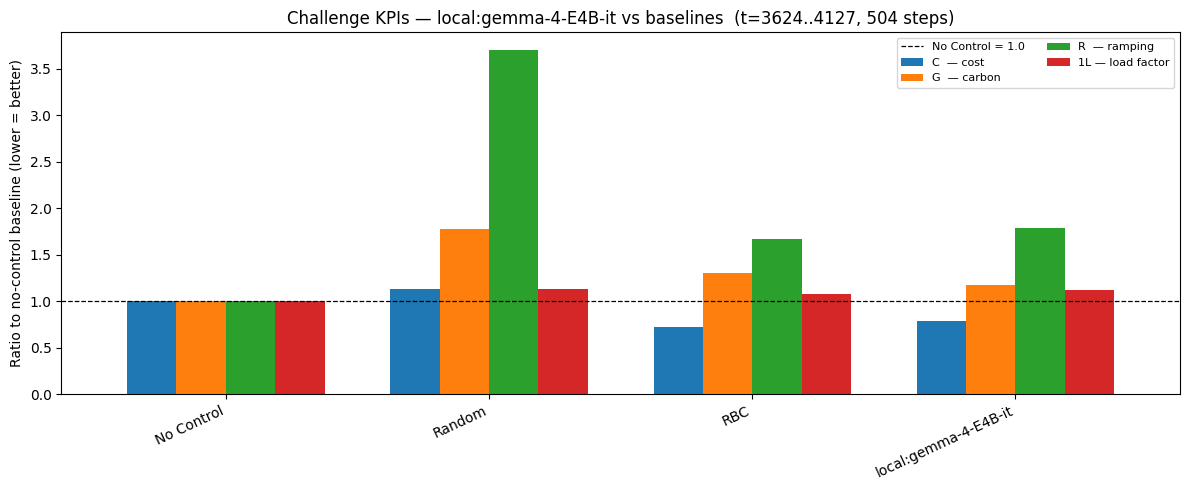

In [20]:
# Bar plot — Challenge KPIs (C, G, R, 1-L)
kpi_cols = ["C  — cost", "G  — carbon", "R  — ramping", "1L — load factor"]
ax = challenge_df[kpi_cols].plot(kind="bar", figsize=(12, 5), width=0.75)
ax.axhline(1.0, color="k", ls="--", lw=0.9, label="No Control = 1.0")
ax.set_ylabel("Ratio to no-control baseline (lower = better)")
ax.set_title(
    f"Challenge KPIs — {slm.label} vs baselines  "
    f"(t={WEEK_START}..{WEEK_START+WEEK_LEN-1}, {WEEK_LEN} steps)"
)
ax.legend(loc="upper right", fontsize=8, ncol=2)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


## § 12 — Per-Building Breakdown

District averages can hide single-building pathologies. The table below reports total reward, mean SoC, peak net, total energy, and action mean / std **per building** — a healthy district total with `std_action > 0.4` on one building means that building is oscillating and the daily-average R metric is averaging the ramping away. Also prints the fallback count (parse failures + retries that returned to zeros) — target is `0/300`.

In [21]:
def per_building_summary(df: pd.DataFrame, label: str) -> pd.DataFrame:
    """Per-building action/SoC/reward summary for the single-agent rollout."""
    rows = []
    for b in range(N_BLDGS):
        rows.append({
            "run":           label,
            "building":      f"B{b}",
            "total_reward":  float(df[f"r{b}"].sum()),
            "mean_soc_pct":  float(df[f"soc{b}"].mean() * 100),
            "peak_net_kW":   float(df[f"net{b}"].max()),
            "total_net_kWh": float(df[f"net{b}"].sum()),
            "mean_action":   float(df[f"a{b}"].mean()),
            "std_action":    float(df[f"a{b}"].std()),
        })
    return pd.DataFrame(rows)


per_b = per_building_summary(slm_df, slm.label)
print(f"Per-building breakdown (buildings {BUILDINGS_RUN}):")
display(per_b.set_index(["run", "building"]).round(4))

# Fallback count
n_fb = sum(1 for r in slm_run["raw_log"] if r["fallback"])
print(f"\nFallbacks: {n_fb}/{WEEK_LEN}  (target: 0)")


Per-building breakdown (buildings [0, 1, 2]):


total_reward  mean_soc_pct  peak_net_kW  \
run                  building                                            
local:gemma-4-E4B-it B0           -883.1579       73.5372       5.8797   
                     B1           -929.5213       72.0153       5.6361   
                     B2           -451.8874       73.4690       3.5873   

                               total_net_kWh  mean_action  std_action  
run                  building                                          
local:gemma-4-E4B-it B0             391.6196       0.0095      0.2006  
                     B1             504.1317       0.0044      0.2029  
                     B2             131.4121       0.0111      0.1608


Fallbacks: 0/504  (target: 0)


## § 13 — Diagnostics

Four behavioural views that the summary tables can't show:

1. **SoC trajectories** — does the SLM actually move the battery, or sit at 50 %? PEAK price windows are shaded gold so price-aligned discharges are visible.
2. **District net load** — the curve `evaluate_v2` integrates to compute C / R / 1−L; visualising it shows where ramping is coming from.
3. **Sample raw responses** — two timesteps printed verbatim, including the `<thought>` block, to check the SLM is reasoning rather than always returning IDLE.
4. **Timing analysis** — tokens/call distribution, throughput (tokens/s), and the fallback rate. Useful when comparing models or tuning `MAX_NEW_TOKENS`.

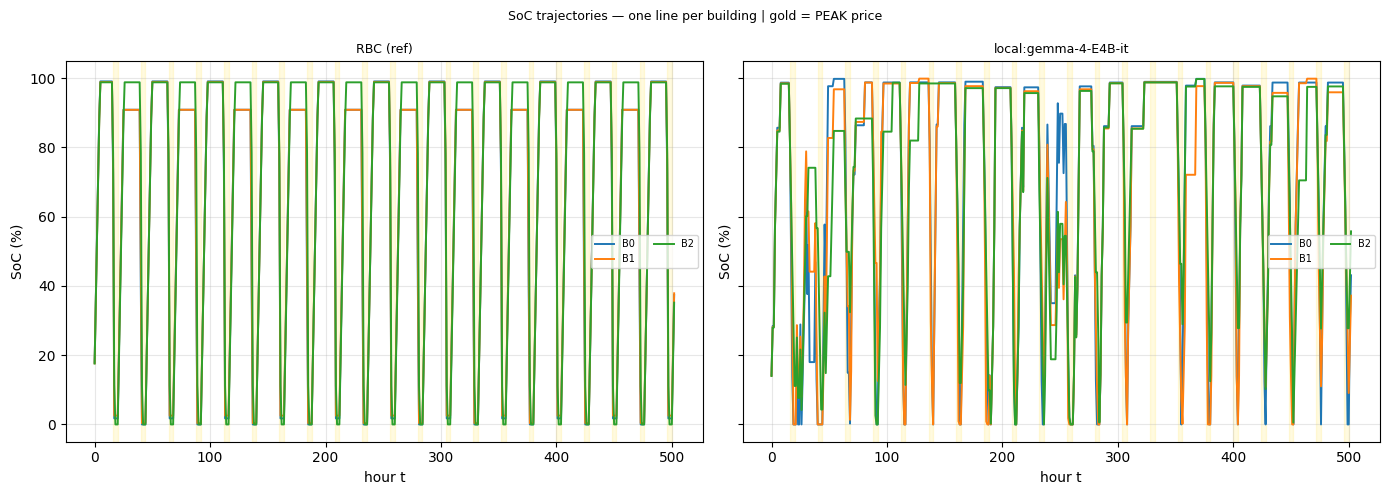

In [22]:
# 13.1  SoC trajectories — one line per building, PEAK price shaded
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

bldg_colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for ax, (df_, label) in zip(axes, [(df_rbc, "RBC (ref)"), (slm_df, slm.label)]):
    for b in range(N_BLDGS):
        ax.plot(df_["t"], df_[f"soc{b}"] * 100,
                label=f"B{b}", lw=1.4, color=bldg_colors[b % len(bldg_colors)])

    peak_mask = (df_["price"] >= PRICE_PEAK_THRESHOLD).values
    in_peak, span_s = False, 0
    for im, is_peak in enumerate(peak_mask):
        if is_peak and not in_peak:
            span_s = im; in_peak = True
        elif not is_peak and in_peak:
            ax.axvspan(span_s, im - 1, color="gold", alpha=0.12); in_peak = False
    if in_peak:
        ax.axvspan(span_s, len(peak_mask) - 1, color="gold", alpha=0.12)

    ax.set_xlabel("hour t"); ax.set_ylabel("SoC (%)")
    ax.set_title(label, fontsize=9)
    ax.legend(ncol=2, fontsize=7); ax.grid(alpha=0.3)

plt.suptitle("SoC trajectories — one line per building | gold = PEAK price", fontsize=9)
plt.tight_layout()
plt.show()


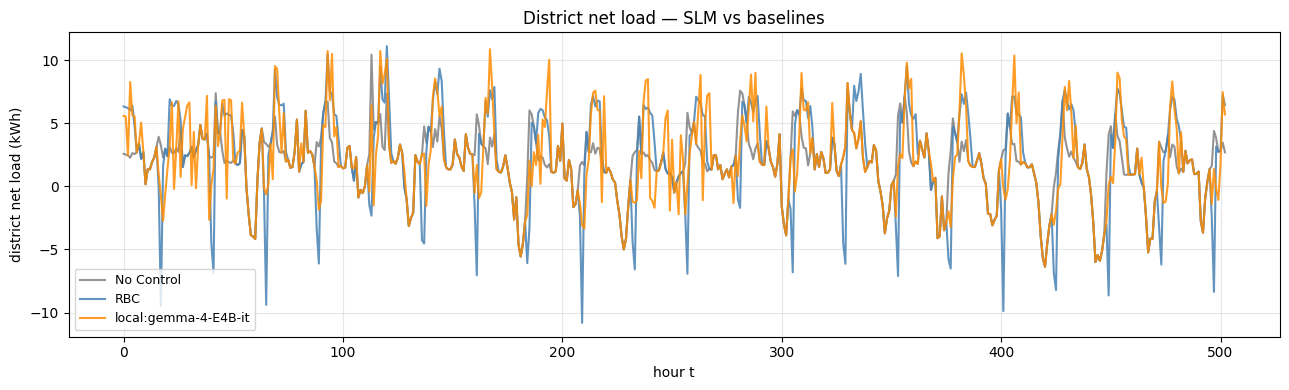

In [23]:
# 13.2  District net load comparison
fig, ax = plt.subplots(figsize=(13, 4))

for df_, lbl, color, ls in [
    (df_noop, "No Control", "gray",       "-"),
    (df_rbc,  "RBC",        "steelblue",  "-"),
    (slm_df,  slm.label,    "darkorange", "-"),
]:
    net = df_[[f"net{i}" for i in range(N_BLDGS)]].sum(axis=1)
    ax.plot(df_["t"], net, label=lbl, lw=1.5, color=color, ls=ls, alpha=0.85)

ax.set_xlabel("hour t")
ax.set_ylabel("district net load (kWh)")
ax.set_title("District net load — SLM vs baselines")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [24]:
# 13.3  Sample raw responses — 2 timesteps
SHOW_STEPS = [10, 80]

log = slm_run["raw_log"]

for step_t in SHOW_STEPS:
    idx = next((i for i, r in enumerate(log) if r["t"] == step_t), None)
    if idx is None:
        continue
    print("=" * 70)
    print(f"t = {step_t}")
    print(f"State:\n{log[idx]['state_text']}")
    print(f"\nResponse (fallback={log[idx]['fallback']}):\n{log[idx]['raw']}")
    print()


t = 10
State:
Month 12, Fri 09:00  |  price=LOW  |  carbon=HIGH
Buildings:
  B0: SoC= 98.7%  load=0.75 kWh  last_net=+0.99 kWh  solar=MID
  B1: SoC= 98.5%  load=2.23 kWh  last_net=+1.01 kWh  solar=MID
  B2: SoC= 98.4%  load=1.03 kWh  last_net=+0.72 kWh  solar=MID

Response (fallback=False):
<thought>All batteries are nearly full. Low price suggests charging is good, but HIGH carbon suggests avoiding grid charging. Solar is MID for all.</thought>
<action building=0>IDLE</action>
<action building=1>IDLE</action>
<action building=2>IDLE</action>

t = 80
State:
Month 1, Mon 07:00  |  price=LOW  |  carbon=MID
Buildings:
  B0: SoC= 86.4%  load=0.99 kWh  last_net=+3.56 kWh  solar=LOW
  B1: SoC= 87.3%  load=0.81 kWh  last_net=+1.52 kWh  solar=LOW
  B2: SoC= 88.3%  load=0.23 kWh  last_net=+0.20 kWh  solar=LOW

Response (fallback=False):
<thought>All batteries are high. Low price/mid carbon favors charging if possible, but solar is low, so IDLE is safest to maintain SoC.</thought>
<action buildi

In [25]:
# 13.4  Timing analysis — tokens generated per call, tokens/second
all_responses = [r["raw"] for r in slm_run["raw_log"]]
token_counts  = [
    len(slm.tokenizer.encode(r, add_special_tokens=False))
    for r in all_responses if r
]

print(f"Total calls          : {len(all_responses)}")
print(f"Tokens generated/call: mean={np.mean(token_counts):.0f}  "
      f"min={min(token_counts)}  max={max(token_counts)}")
print(f"Total tokens         : {sum(token_counts):,}")

# Throughput from the realistic warmup
_warmup_toks = len(slm.tokenizer.encode(_resp, add_special_tokens=False))
_tok_per_s   = _warmup_toks / (_wt1 - _wt0) if (_wt1 - _wt0) > 0 else 0
print(f"Approx throughput    : {_tok_per_s:.0f} tokens/s  "
      f"({_tok_per_s * 60:.0f} tokens/min)")

# Fallback rate
all_fb = [r["fallback"] for r in slm_run["raw_log"]]
print(f"Fallback rate        : {sum(all_fb)}/{len(all_fb)} "
      f"({100*sum(all_fb)/len(all_fb):.1f}%)  (target: 0%)")


Total calls          : 503
Tokens generated/call: mean=72  min=63  max=90
Total tokens         : 36,416
Approx throughput    : 3 tokens/s  (165 tokens/min)
Fallback rate        : 0/503 (0.0%)  (target: 0%)
